# HBL BiLSTM Stock Return Model — Evaluation & Predictions
**Dataset:** HBL OHLCV + Dawn News Sentiment | **Period:** Jan 2015 – Aug 2025  
**Model:** Bidirectional LSTM (Regression) predicting `log_return_next`

## 0. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score
)
from scipy import stats

# Plot style
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#3a3d4d',
    'axes.labelcolor':  '#e0e0e0',
    'xtick.color':      '#e0e0e0',
    'ytick.color':      '#e0e0e0',
    'text.color':       '#e0e0e0',
    'grid.color':       '#2a2d3d',
    'grid.linestyle':   '--',
    'grid.alpha':       0.5,
    'font.family':      'DejaVu Sans',
    'axes.titlesize':   13,
    'axes.labelsize':   11,
})

ACCENT   = '#00c8ff'
ACCENT2  = '#ff6b6b'
ACCENT3  = '#7bed9f'

print('TensorFlow:', tf.__version__)
print('Setup complete ✓')

TensorFlow: 2.20.0
Setup complete ✓


## 1. Load Data, Model & Scaler

In [2]:
# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv("hbl_merged_dataset_clean.csv")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

# ── Feature engineering (mirror training exactly) ────────────────────────────
df["ret_1"]  = df["log_return"]
df["ret_5"]  = np.log(df["Close"]).diff(5)
df["ret_10"] = np.log(df["Close"]).diff(10)

df["vol_5"]  = df["log_return"].rolling(5).std()
df["vol_10"] = df["log_return"].rolling(10).std()
df["vol_20"] = df["log_return"].rolling(20).std()

df["hl_pct"] = (df["High"] - df["Low"]) / df["Close"]
df["oc_pct"] = (df["Close"] - df["Open"]) / df["Open"]

df["log_volume"] = np.log1p(df["Volume"])

df["sent_3"]     = df["daily_sentiment"].rolling(3).mean()
df["sent_7"]     = df["daily_sentiment"].rolling(7).mean()
df["news_shock"] = df["daily_sentiment"] * np.log1p(df["daily_news_count"])

df = df.dropna().reset_index(drop=True)

FEATURES = [
    "ret_1","ret_5","ret_10",
    "vol_5","vol_10","vol_20",
    "hl_pct","oc_pct",
    "log_volume",
    "daily_sentiment","daily_news_count","news_shock",
    "sent_3","sent_7",
    "quarterly_sentiment","annual_sentiment"
]
TARGET = "log_return_next"

X = df[FEATURES].values.astype(np.float32)
y = df[TARGET].values.astype(np.float32)
dates = df["date"].values

# ── Train/Val/Test split ──────────────────────────────────────────────────────
n = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

X_train, y_train = X[:train_end], y[:train_end]
X_val,   y_val   = X[train_end:val_end], y[train_end:val_end]
X_test,  y_test  = X[val_end:], y[val_end:]

# ── Load scaler & scale ───────────────────────────────────────────────────────
scaler  = joblib.load("feature_scaler.pkl")
X_train = scaler.transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

# ── Sequences ─────────────────────────────────────────────────────────────────
SEQ_LEN = 30

def make_sequences(X, y, dates, seq_len=30):
    Xs, ys, ds = [], [], []
    for i in range(seq_len, len(X)):
        Xs.append(X[i-seq_len:i])
        ys.append(y[i])
        ds.append(dates[i])
    return np.array(Xs), np.array(ys), np.array(ds)

# We need dates per split
dates_train = dates[:train_end]
dates_val   = dates[train_end:val_end]
dates_test  = dates[val_end:]

Xtr, ytr, dtr = make_sequences(X_train, y_train, dates_train, SEQ_LEN)
Xva, yva, dva = make_sequences(X_val,   y_val,   dates_val,   SEQ_LEN)
Xte, yte, dte = make_sequences(X_test,  y_test,  dates_test,  SEQ_LEN)

# ── Load model ────────────────────────────────────────────────────────────────
model = tf.keras.models.load_model("bilstm_return_regression.keras")

print(f"Dataset rows : {len(df):,}  ({df['date'].min().date()} → {df['date'].max().date()})")
print(f"Train seqs   : {len(Xtr):,}")
print(f"Val seqs     : {len(Xva):,}")
print(f"Test seqs    : {len(Xte):,}")
print("Model & scaler loaded ✓")

Dataset rows : 2,484  (2016-01-27 → 2025-08-28)
Train seqs   : 1,708
Val seqs     : 343
Test seqs    : 343
Model & scaler loaded ✓


## 2. Generate Predictions on All Splits

In [3]:
pred_train = model.predict(Xtr, verbose=0).flatten()
pred_val   = model.predict(Xva, verbose=0).flatten()
pred_test  = model.predict(Xte, verbose=0).flatten()

print("Predictions generated ✓")
print(f"Test predictions range: [{pred_test.min():.4f}, {pred_test.max():.4f}]")
print(f"Test actuals range    : [{yte.min():.4f}, {yte.max():.4f}]")

Predictions generated ✓
Test predictions range: [-0.0099, 0.0069]
Test actuals range    : [-0.0781, 0.0953]


## 3. Evaluation Metrics — All Splits

In [4]:
def compute_metrics(actual, predicted, split_name):
    rmse  = np.sqrt(mean_squared_error(actual, predicted))
    mae   = mean_absolute_error(actual, predicted)
    r2    = r2_score(actual, predicted)
    corr  = np.corrcoef(actual, predicted)[0, 1]
    # Directional accuracy: did we predict sign correctly?
    da    = np.mean(np.sign(actual) == np.sign(predicted)) * 100
    # Mean Absolute Percentage Error (on returns, guard div/0)
    mape  = np.mean(np.abs((actual - predicted) / (np.abs(actual) + 1e-8))) * 100
    
    return {
        'Split': split_name,
        'RMSE':  round(rmse, 6),
        'MAE':   round(mae, 6),
        'R²':    round(r2, 4),
        'Pearson r': round(corr, 4),
        'Dir. Acc %': round(da, 2),
        'MAPE %': round(mape, 2)
    }

metrics = pd.DataFrame([
    compute_metrics(ytr, pred_train, 'Train'),
    compute_metrics(yva, pred_val,   'Validation'),
    compute_metrics(yte, pred_test,  'Test'),
])

metrics.set_index('Split', inplace=True)
print("\n── Evaluation Metrics ──────────────────────────────────")
print(metrics.to_string())
print()

# Interpretation guide
r2_test = metrics.loc['Test', 'R²']
da_test = metrics.loc['Test', 'Dir. Acc %']

print(f"📌 R² = {r2_test}  → model explains {r2_test*100:.1f}% of test variance")
print(f"📌 Directional Accuracy = {da_test}%  → predicts up/down correctly {da_test:.1f}% of the time")
print(f"📌 Baseline Dir. Acc (random) = 50%")


── Evaluation Metrics ──────────────────────────────────
                RMSE       MAE      R²  Pearson r  Dir. Acc %        MAPE %
Split                                                                      
Train       0.017967  0.012662  0.0133     0.1507       49.12  9.397746e+05
Validation  0.020006  0.012528  0.0055     0.1022       46.94  7.655019e+05
Test        0.023588  0.016013 -0.0413     0.0165       51.60  1.208102e+06

📌 R² = -0.0413  → model explains -4.1% of test variance
📌 Directional Accuracy = 51.6%  → predicts up/down correctly 51.6% of the time
📌 Baseline Dir. Acc (random) = 50%


## 4. Visualisation A — Actual vs Predicted (Test Set)

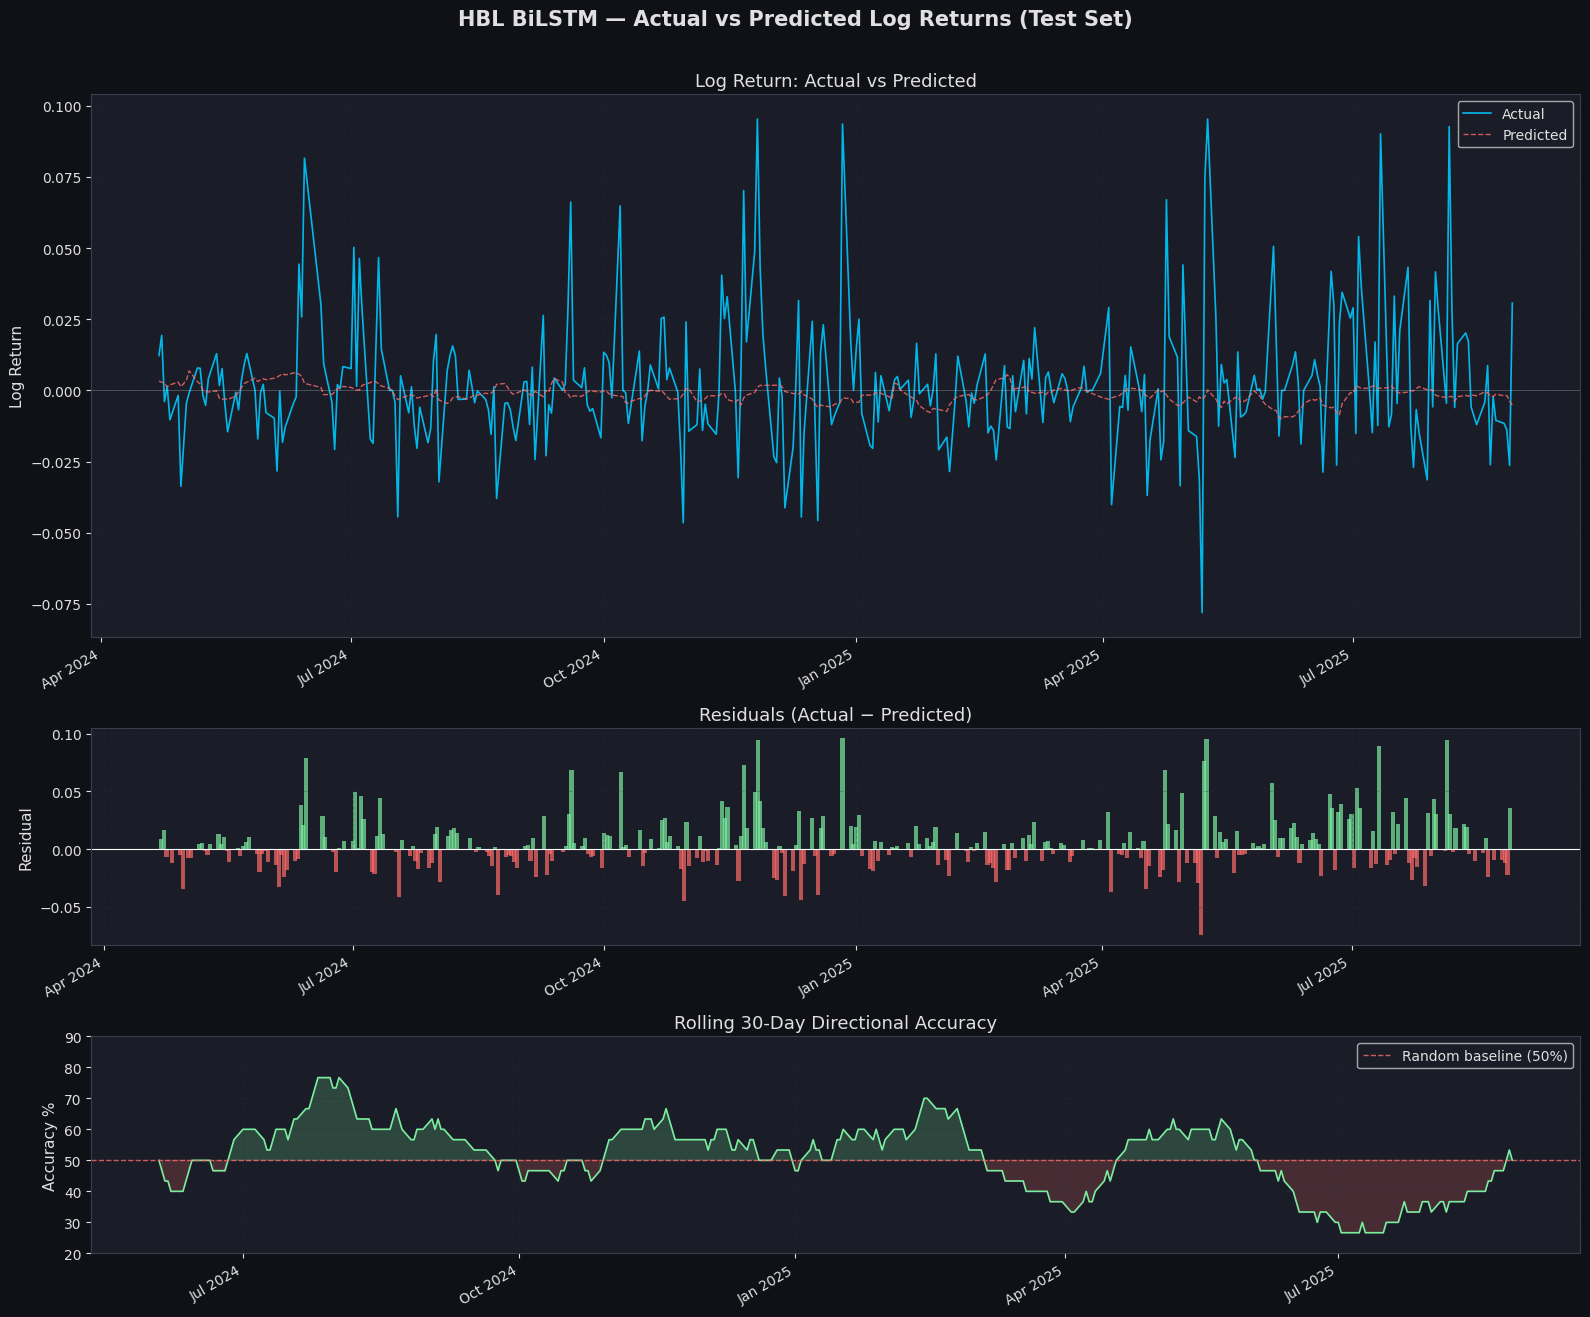

Saved → plot_actual_vs_predicted.png


In [5]:
fig, axes = plt.subplots(3, 1, figsize=(16, 13), gridspec_kw={'height_ratios': [3, 1.2, 1.2]})
fig.suptitle('HBL BiLSTM — Actual vs Predicted Log Returns (Test Set)', 
             fontsize=15, fontweight='bold', y=1.01)

test_dates = pd.to_datetime(dte)

# ── Panel 1: Time-series overlay ─────────────────────────────────────────────
ax = axes[0]
ax.plot(test_dates, yte,       color=ACCENT,  lw=1.2, alpha=0.9, label='Actual')
ax.plot(test_dates, pred_test, color=ACCENT2, lw=1.0, alpha=0.8, label='Predicted', linestyle='--')
ax.axhline(0, color='white', lw=0.5, alpha=0.3)
ax.set_title('Log Return: Actual vs Predicted')
ax.set_ylabel('Log Return')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# ── Panel 2: Residuals (actual - predicted) ───────────────────────────────────
residuals = yte - pred_test
ax2 = axes[1]
ax2.bar(test_dates, residuals, color=np.where(residuals >= 0, ACCENT3, ACCENT2), 
        alpha=0.7, width=1.5)
ax2.axhline(0, color='white', lw=0.8)
ax2.set_title('Residuals (Actual − Predicted)')
ax2.set_ylabel('Residual')
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax2.get_xticklabels(), rotation=30, ha='right')

# ── Panel 3: Rolling Directional Accuracy (30-day window) ────────────────────
correct = (np.sign(yte) == np.sign(pred_test)).astype(float)
roll_da = pd.Series(correct).rolling(30).mean() * 100

ax3 = axes[2]
ax3.plot(test_dates, roll_da, color=ACCENT3, lw=1.2)
ax3.axhline(50, color=ACCENT2, lw=1, linestyle='--', alpha=0.8, label='Random baseline (50%)')
ax3.fill_between(test_dates, 50, roll_da, where=(roll_da >= 50), 
                  color=ACCENT3, alpha=0.2)
ax3.fill_between(test_dates, 50, roll_da, where=(roll_da < 50), 
                  color=ACCENT2, alpha=0.2)
ax3.set_title('Rolling 30-Day Directional Accuracy')
ax3.set_ylabel('Accuracy %')
ax3.set_ylim(20, 90)
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax3.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.setp(ax3.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('plot_actual_vs_predicted.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Saved → plot_actual_vs_predicted.png')

## 5. Visualisation B — Residual Analysis

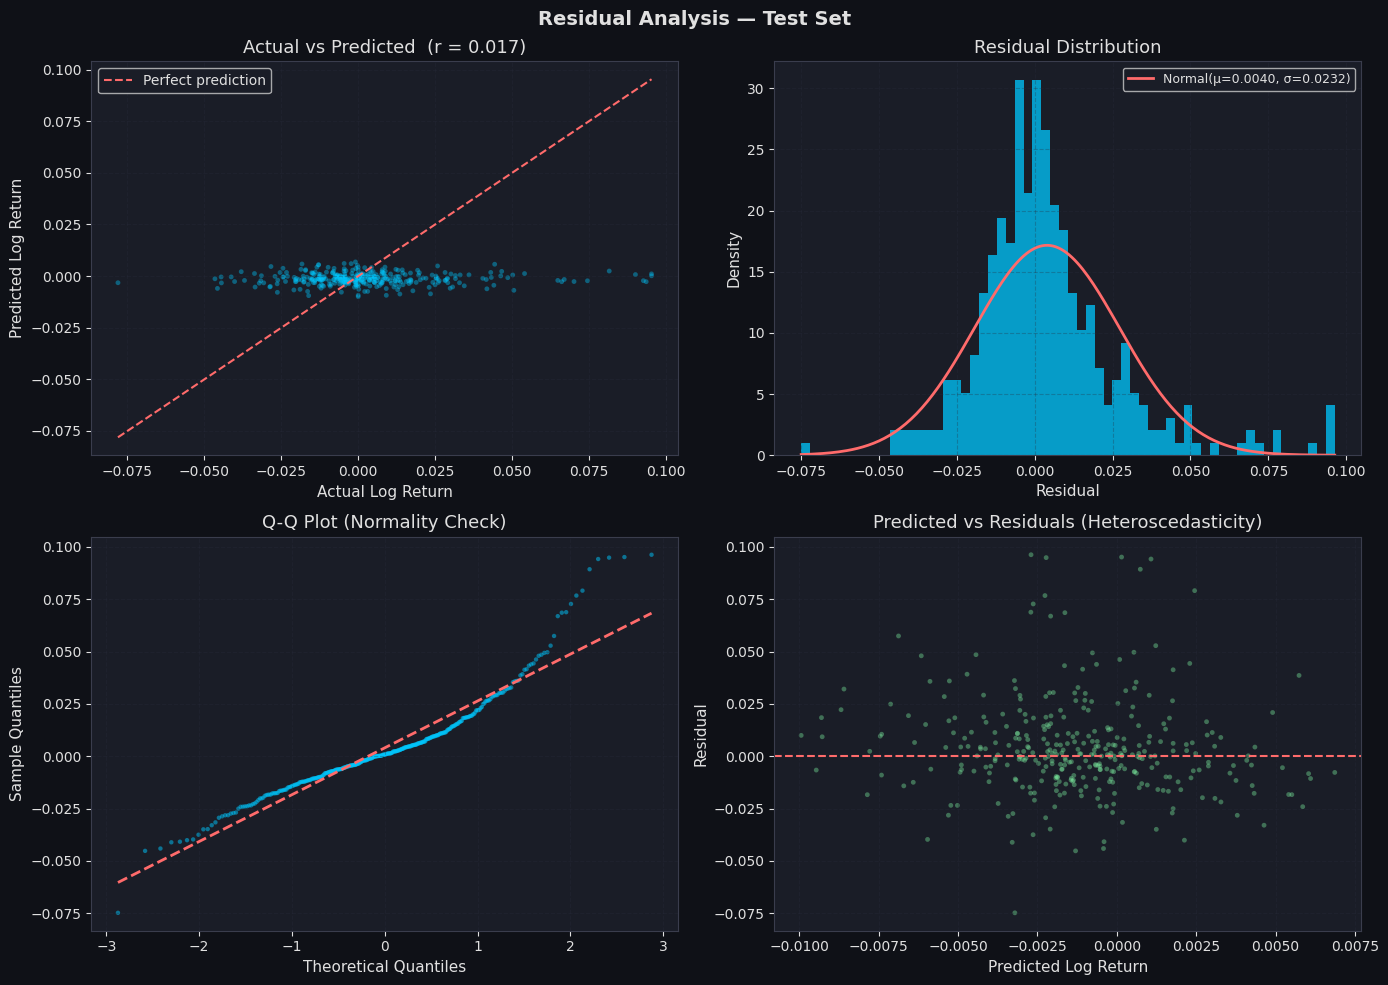

Saved → plot_residual_analysis.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Residual Analysis — Test Set', fontsize=14, fontweight='bold')

residuals = yte - pred_test

# ── 1. Scatter: Actual vs Predicted ──────────────────────────────────────────
ax = axes[0, 0]
ax.scatter(yte, pred_test, color=ACCENT, alpha=0.4, s=12, edgecolors='none')
lims = [min(yte.min(), pred_test.min()), max(yte.max(), pred_test.max())]
ax.plot(lims, lims, color=ACCENT2, lw=1.5, linestyle='--', label='Perfect prediction')
ax.set_xlabel('Actual Log Return')
ax.set_ylabel('Predicted Log Return')
ax.set_title(f'Actual vs Predicted  (r = {np.corrcoef(yte, pred_test)[0,1]:.3f})')
ax.legend()
ax.grid(True, alpha=0.3)

# ── 2. Residual distribution ──────────────────────────────────────────────────
ax = axes[0, 1]
ax.hist(residuals, bins=60, color=ACCENT, alpha=0.75, edgecolor='none', density=True)
xr = np.linspace(residuals.min(), residuals.max(), 200)
mu, sigma = residuals.mean(), residuals.std()
ax.plot(xr, stats.norm.pdf(xr, mu, sigma), color=ACCENT2, lw=2, label=f'Normal(μ={mu:.4f}, σ={sigma:.4f})')
ax.set_xlabel('Residual')
ax.set_ylabel('Density')
ax.set_title('Residual Distribution')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ── 3. Q-Q plot ───────────────────────────────────────────────────────────────
ax = axes[1, 0]
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
ax.scatter(osm, osr, color=ACCENT, alpha=0.5, s=10, edgecolors='none')
ax.plot(osm, slope*np.array(osm)+intercept, color=ACCENT2, lw=2, linestyle='--')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles')
ax.set_title('Q-Q Plot (Normality Check)')
ax.grid(True, alpha=0.3)

# ── 4. Predicted vs Residuals (heteroscedasticity check) ─────────────────────
ax = axes[1, 1]
ax.scatter(pred_test, residuals, color=ACCENT3, alpha=0.4, s=12, edgecolors='none')
ax.axhline(0, color=ACCENT2, lw=1.5, linestyle='--')
ax.set_xlabel('Predicted Log Return')
ax.set_ylabel('Residual')
ax.set_title('Predicted vs Residuals (Heteroscedasticity)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plot_residual_analysis.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Saved → plot_residual_analysis.png')

## 6. Visualisation C — Cumulative Return: Strategy Backtest

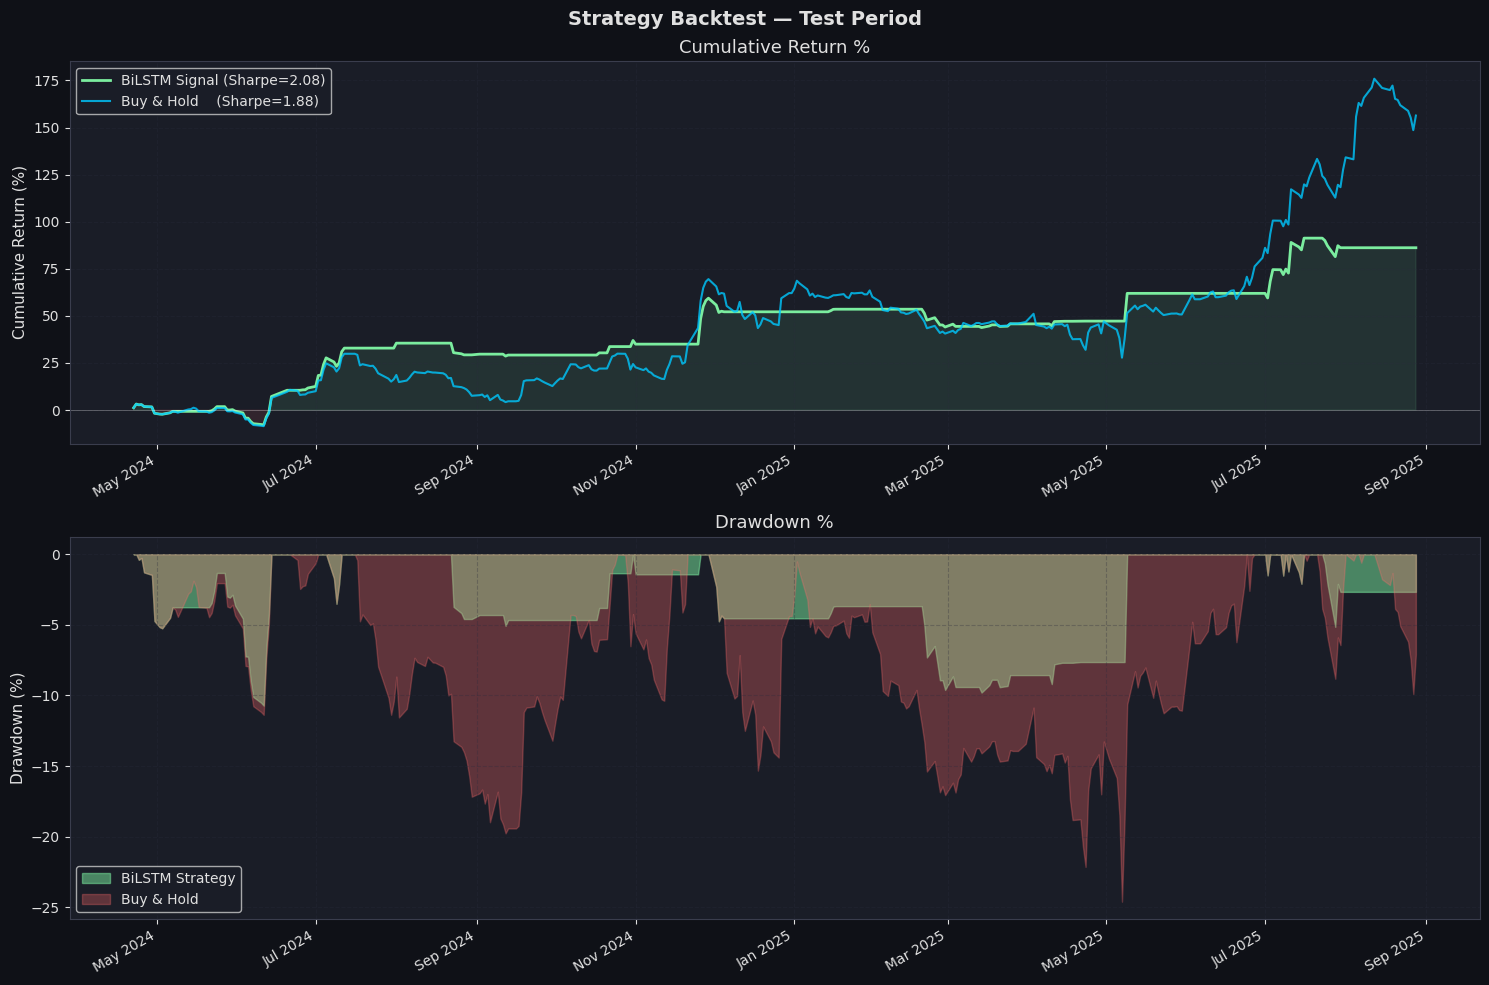


── Backtest Summary ────────────────────────
Strategy total return : 86.19%
Buy & Hold total return: 156.36%
Strategy Sharpe        : 2.077
Buy & Hold Sharpe      : 1.885
Strategy Max Drawdown  : -10.72%


In [7]:
"""
Simple signal backtest:
  - If model predicts positive return → LONG (+1)
  - If model predicts negative return → FLAT (0)  [no short selling]
  - Buy & Hold = always long
Returns are log returns, so we can sum them to get cumulative log return,
then convert: exp(cumsum) - 1 for % P&L.
"""

signal = np.where(pred_test > 0, 1, 0)   # 1 = long, 0 = flat
strategy_returns  = signal * yte          # strategy daily log return
buyhold_returns   = yte                   # buy & hold

cum_strategy = np.exp(np.cumsum(strategy_returns)) - 1
cum_buyhold  = np.exp(np.cumsum(buyhold_returns))  - 1

# Annualised Sharpe (252 trading days)
sharpe_strategy = (strategy_returns.mean() / (strategy_returns.std() + 1e-9)) * np.sqrt(252)
sharpe_buyhold  = (buyhold_returns.mean()  / (buyhold_returns.std()  + 1e-9)) * np.sqrt(252)

fig, axes = plt.subplots(2, 1, figsize=(15, 10))
fig.suptitle('Strategy Backtest — Test Period', fontsize=14, fontweight='bold')

# ── Cumulative returns ────────────────────────────────────────────────────────
ax = axes[0]
ax.plot(test_dates, cum_strategy * 100, color=ACCENT3, lw=2,   label=f'BiLSTM Signal (Sharpe={sharpe_strategy:.2f})')
ax.plot(test_dates, cum_buyhold  * 100, color=ACCENT,  lw=1.5, label=f'Buy & Hold    (Sharpe={sharpe_buyhold:.2f})', alpha=0.8)
ax.axhline(0, color='white', lw=0.5, alpha=0.4)
ax.fill_between(test_dates, 0, cum_strategy*100, where=(cum_strategy>=0), 
                color=ACCENT3, alpha=0.1)
ax.fill_between(test_dates, 0, cum_strategy*100, where=(cum_strategy<0), 
                color=ACCENT2, alpha=0.1)
ax.set_title('Cumulative Return %')
ax.set_ylabel('Cumulative Return (%)')
ax.legend()
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# ── Drawdown ──────────────────────────────────────────────────────────────────
def max_drawdown_series(cum_ret):
    wealth = 1 + cum_ret
    roll_max = np.maximum.accumulate(wealth)
    dd = (wealth - roll_max) / roll_max
    return dd * 100

ax2 = axes[1]
dd_strat = max_drawdown_series(cum_strategy)
dd_bh    = max_drawdown_series(cum_buyhold)
ax2.fill_between(test_dates, dd_strat, 0, color=ACCENT3, alpha=0.5, label='BiLSTM Strategy')
ax2.fill_between(test_dates, dd_bh,   0, color=ACCENT2, alpha=0.3, label='Buy & Hold')
ax2.set_title('Drawdown %')
ax2.set_ylabel('Drawdown (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.setp(ax2.get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('plot_backtest.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

print(f"\n── Backtest Summary ────────────────────────")
print(f"Strategy total return : {cum_strategy[-1]*100:.2f}%")
print(f"Buy & Hold total return: {cum_buyhold[-1]*100:.2f}%")
print(f"Strategy Sharpe        : {sharpe_strategy:.3f}")
print(f"Buy & Hold Sharpe      : {sharpe_buyhold:.3f}")
print(f"Strategy Max Drawdown  : {dd_strat.min():.2f}%")

## 7. Visualisation D — Feature Importance via Permutation

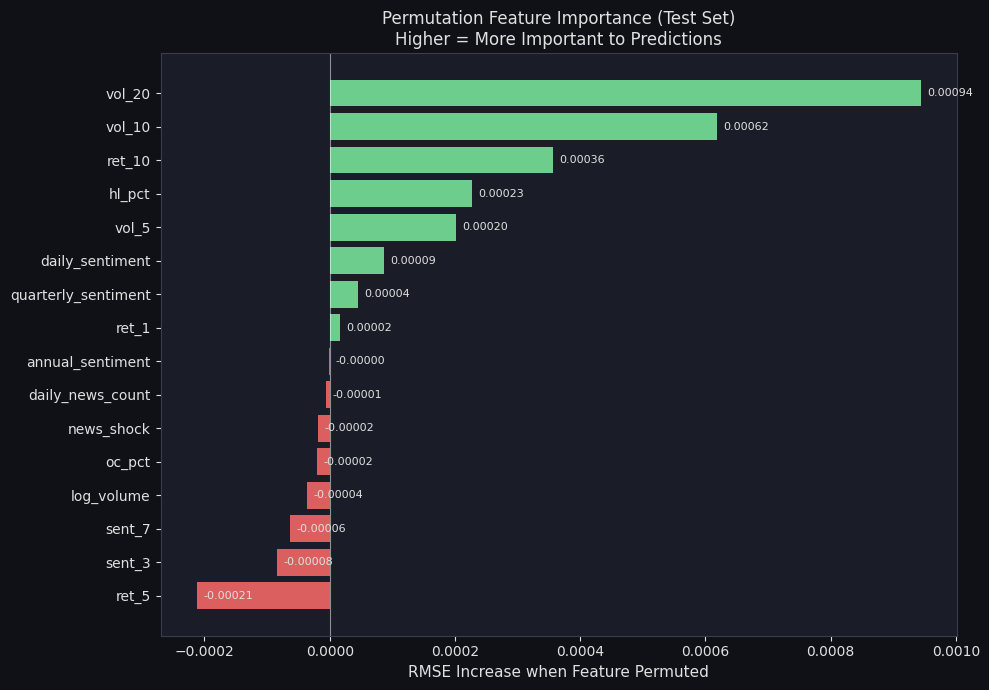

Saved → plot_feature_importance.png


In [8]:
"""
Permutation Feature Importance:
For each feature, shuffle its values across all timesteps in Xte,
repredict, and measure the increase in RMSE. Larger increase = more important.
"""

base_rmse = np.sqrt(mean_squared_error(yte, pred_test))
importances = {}

for i, feat in enumerate(FEATURES):
    Xte_perm = Xte.copy()
    # Shuffle feature i across all samples
    idx = np.random.permutation(Xte_perm.shape[0])
    Xte_perm[:, :, i] = Xte_perm[idx, :, i]
    perm_pred = model.predict(Xte_perm, verbose=0).flatten()
    perm_rmse = np.sqrt(mean_squared_error(yte, perm_pred))
    importances[feat] = perm_rmse - base_rmse

imp_df = pd.Series(importances).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))
colors = [ACCENT3 if v > 0 else ACCENT2 for v in imp_df.values]
bars = ax.barh(imp_df.index, imp_df.values, color=colors, alpha=0.85, edgecolor='none')
ax.axvline(0, color='white', lw=0.8, alpha=0.5)
ax.set_xlabel('RMSE Increase when Feature Permuted')
ax.set_title('Permutation Feature Importance (Test Set)\n'
             'Higher = More Important to Predictions', fontsize=12)

for bar, val in zip(bars, imp_df.values):
    ax.text(val + 0.00001, bar.get_y() + bar.get_height()/2,
            f'{val:.5f}', va='center', fontsize=8, color='#e0e0e0')

plt.tight_layout()
plt.savefig('plot_feature_importance.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Saved → plot_feature_importance.png')

## 8. Predictions — Export to CSV

In [9]:
# Build a clean predictions dataframe for the test period
test_df = pd.DataFrame({
    'date':             pd.to_datetime(dte),
    'actual_log_ret':   yte,
    'predicted_log_ret': pred_test,
    'residual':          yte - pred_test,
    'signal':            np.where(pred_test > 0, 'LONG', 'FLAT'),
    'direction_correct': np.sign(yte) == np.sign(pred_test),
})

# Attach Close price for context
close_test = df.loc[val_end + SEQ_LEN:, 'Close'].reset_index(drop=True)
if len(close_test) == len(test_df):
    test_df['Close'] = close_test.values

test_df.to_csv('hbl_test_predictions.csv', index=False)
print(f"Saved {len(test_df)} test predictions → hbl_test_predictions.csv")
print()
print(test_df.head(10).to_string(index=False))

Saved 343 test predictions → hbl_test_predictions.csv

      date  actual_log_ret  predicted_log_ret  residual signal  direction_correct      Close
2024-04-22        0.012236           0.003275  0.008961   LONG               True  98.240929
2024-04-23        0.019305           0.002826  0.016479   LONG               True  99.450394
2024-04-24       -0.003984           0.002595 -0.006579   LONG              False 101.388962
2024-04-25        0.001358           0.001200  0.000158   LONG               True 100.985802
2024-04-26       -0.010317           0.001929 -0.012246   LONG              False 101.123047
2024-04-29       -0.001801           0.002885 -0.004686   LONG              False 100.085136
2024-04-30       -0.033703           0.001243 -0.034946   LONG              False  99.905006
2024-05-02       -0.004539           0.003564 -0.008103   LONG              False  96.594002
2024-05-03       -0.000893           0.006866 -0.007758   LONG              False  96.156540
2024-05-06     

## 9. Predict on New / Unseen Data
Use this cell to generate a prediction for any new row of data.

In [10]:
def predict_next_return(df_raw, model, scaler, features=FEATURES, seq_len=SEQ_LEN):
    """
    Given the full dataframe (with feature engineering already applied),
    predict the NEXT day's log return using the last `seq_len` rows.

    Parameters
    ----------
    df_raw   : pd.DataFrame — full dataset with all features computed
    model    : loaded Keras model
    scaler   : fitted StandardScaler
    features : list of feature column names
    seq_len  : int — sequence length (must match training, 30)

    Returns
    -------
    dict with predicted log return, predicted direction, and approx price change %
    """
    assert len(df_raw) >= seq_len, f"Need at least {seq_len} rows of data."

    # Take last seq_len rows
    window = df_raw[features].values[-seq_len:].astype(np.float32)
    window_scaled = scaler.transform(window)         # shape: (seq_len, n_features)
    X_input = window_scaled[np.newaxis, :, :]        # shape: (1, seq_len, n_features)

    pred_log_ret = model.predict(X_input, verbose=0)[0, 0]
    pred_pct     = (np.exp(pred_log_ret) - 1) * 100  # convert log return → % change
    direction    = 'UP ▲' if pred_log_ret > 0 else 'DOWN ▼'

    last_date  = df_raw['date'].iloc[-1]
    last_close = df_raw['Close'].iloc[-1]

    result = {
        'As of date':              str(last_date.date()),
        'Last Close (PKR)':        round(last_close, 2),
        'Predicted log return':    round(float(pred_log_ret), 6),
        'Predicted % change':      round(float(pred_pct), 3),
        'Predicted next close ~':  round(last_close * np.exp(pred_log_ret), 2),
        'Direction':               direction,
        'Signal':                  'LONG' if pred_log_ret > 0 else 'FLAT'
    }
    return result


# ── Run prediction on the last available window ───────────────────────────────
result = predict_next_return(df, model, scaler)

print("\n" + "═" * 45)
print("  HBL NEXT-DAY PREDICTION")
print("═" * 45)
for k, v in result.items():
    print(f"  {k:<30} {v}")
print("═" * 45)


═════════════════════════════════════════════
  HBL NEXT-DAY PREDICTION
═════════════════════════════════════════════
  As of date                     2025-08-28
  Last Close (PKR)               244.24
  Predicted log return           -0.004868
  Predicted % change             -0.486
  Predicted next close ~         243.06
  Direction                      DOWN ▼
  Signal                         FLAT
═════════════════════════════════════════════


## 10. Rolling Predictions — Full Timeline View

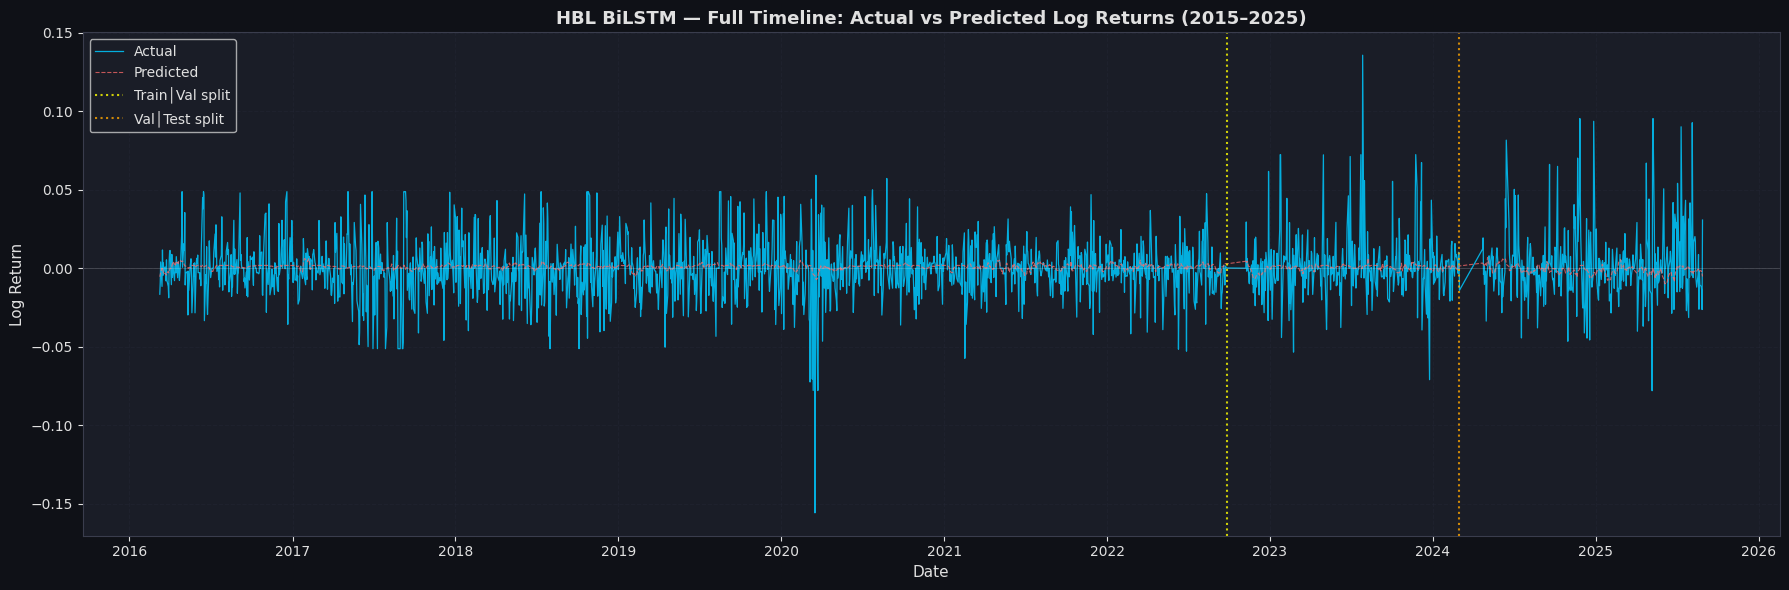

Saved → plot_full_timeline.png


In [11]:
# Combine all splits for a full timeline view
all_dates = np.concatenate([dtr, dva, dte])
all_actual = np.concatenate([ytr, yva, yte])
all_pred   = np.concatenate([pred_train, pred_val, pred_test])
split_boundary_val  = pd.to_datetime(dtr[-1])
split_boundary_test = pd.to_datetime(dva[-1])

fig, ax = plt.subplots(figsize=(18, 6))
all_dt = pd.to_datetime(all_dates)

ax.plot(all_dt, all_actual, color=ACCENT,  lw=0.9, alpha=0.85, label='Actual')
ax.plot(all_dt, all_pred,   color=ACCENT2, lw=0.8, alpha=0.75, label='Predicted', linestyle='--')

ax.axvline(split_boundary_val,  color='yellow', lw=1.5, linestyle=':', alpha=0.8, label='Train│Val split')
ax.axvline(split_boundary_test, color='orange', lw=1.5, linestyle=':', alpha=0.8, label='Val│Test split')
ax.axhline(0, color='white', lw=0.4, alpha=0.3)

ax.set_title('HBL BiLSTM — Full Timeline: Actual vs Predicted Log Returns (2015–2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Log Return')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())

plt.tight_layout()
plt.savefig('plot_full_timeline.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print('Saved → plot_full_timeline.png')

## 11. Final Summary Card

In [12]:
print("\n" + "═" * 60)
print("  HBL BiLSTM MODEL — FINAL EVALUATION SUMMARY")
print("═" * 60)
print(f"  Dataset        : Jan 2015 – Aug 2025 (HBL + Dawn Sentiment)")
print(f"  Features       : {len(FEATURES)} (returns, volatility, OHLCV, sentiment)")
print(f"  Sequence length: {SEQ_LEN} trading days")
print()
print(metrics.to_string())
print()
print(f"  Backtest (Test Period)")
print(f"    Strategy Return : {cum_strategy[-1]*100:.2f}%")
print(f"    B&H Return      : {cum_buyhold[-1]*100:.2f}%")
print(f"    Strategy Sharpe : {sharpe_strategy:.3f}")
print(f"    B&H Sharpe      : {sharpe_buyhold:.3f}")
print()
print(f"  Top 3 most important features (permutation):")
top3 = pd.Series(importances).sort_values(ascending=False).head(3)
for feat, val in top3.items():
    print(f"    {feat:<25} ΔRMSE = {val:.6f}")
print("═" * 60)


════════════════════════════════════════════════════════════
  HBL BiLSTM MODEL — FINAL EVALUATION SUMMARY
════════════════════════════════════════════════════════════
  Dataset        : Jan 2015 – Aug 2025 (HBL + Dawn Sentiment)
  Features       : 16 (returns, volatility, OHLCV, sentiment)
  Sequence length: 30 trading days

                RMSE       MAE      R²  Pearson r  Dir. Acc %        MAPE %
Split                                                                      
Train       0.017967  0.012662  0.0133     0.1507       49.12  9.397746e+05
Validation  0.020006  0.012528  0.0055     0.1022       46.94  7.655019e+05
Test        0.023588  0.016013 -0.0413     0.0165       51.60  1.208102e+06

  Backtest (Test Period)
    Strategy Return : 86.19%
    B&H Return      : 156.36%
    Strategy Sharpe : 2.077
    B&H Sharpe      : 1.885

  Top 3 most important features (permutation):
    vol_20                    ΔRMSE = 0.000944
    vol_10                    ΔRMSE = 0.000619
    ret_